In [11]:
# 1. Setup
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure repo root is on the path for thesis_config import.
root = Path.cwd()
while not (root / "thesis_config.py").exists() and root != root.parent:
    root = root.parent
sys.path.insert(0, str(root))

import thesis_config as cfg

np.random.seed(42)

per_call_path = cfg.GOLD / f"nli_{cfg.RUN_PROFILE}.parquet"
df = pd.read_parquet(per_call_path)

print("Per-call gold path:", per_call_path)
print("Shape:", df.shape)
print("Engines:", sorted(df['engine'].unique().tolist()))
print("Queries per engine:")
print(df.groupby('engine')['query_id'].nunique().sort_values())
runs_per_cell = df.groupby(['engine', 'query_id']).size()
print("Runs per (engine, query_id) cell:")
print(runs_per_cell.value_counts().sort_index())

expected_queries = 100
expected_engines = 5
expected_k = 3
expected_rows = expected_queries * expected_engines * expected_k

assert df.shape[0] == expected_rows, (
    f"Expected {expected_rows} rows (100 queries x 5 engines x 3 runs), got {df.shape[0]}"
 )
assert df['query_id'].nunique() == expected_queries, (
    f"Expected {expected_queries} unique queries, got {df['query_id'].nunique()}"
 )
assert df['engine'].nunique() == expected_engines, (
    f"Expected {expected_engines} engines, got {df['engine'].nunique()}"
 )
assert runs_per_cell.min() == expected_k and runs_per_cell.max() == expected_k, (
    f"Expected {expected_k} runs per cell, got min={runs_per_cell.min()} max={runs_per_cell.max()}"
 )

fig_dir = cfg.ROOT / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)
fig_dir

Per-call gold path: /Users/ganenthraravindran/Desktop/Thesis Data Pilot/data/pilot/gold/nli_pilot.parquet
Shape: (1500, 14)
Engines: ['chatgpt', 'claude', 'gemini', 'kimi', 'perplexity']
Queries per engine:
engine
chatgpt       100
claude        100
gemini        100
kimi          100
perplexity    100
Name: query_id, dtype: int64
Runs per (engine, query_id) cell:
3    500
Name: count, dtype: int64


PosixPath('/Users/ganenthraravindran/Desktop/Thesis Data Pilot/figures')

# 2. Bootstrap convergence — method explanation
We use bootstrap resampling to estimate how the standard error (SE) of each metric’s mean changes as k increases.
This provides a convergence curve that indicates how much additional stability we gain by adding repeats.
Here it serves as a robustness check against the literature-derived minimum k=7-8 (Schulte et al., 2026), not as a basis for changing k.
Because the pilot contains only k=3 real observations per (engine × query) cell, we can credibly assess convergence up to about k=5–6, but should not extrapolate to k=10+ from this base.
Bootstrap at k>3 samples with replacement from the three observed runs, which is legitimate for variance estimation but still limited by the small underlying sample.

In [12]:
# 3. Bootstrap function
def bootstrap_se_at_k(values, k, n_iterations=1000, rng=None):
    """
    Estimate the standard error of the mean when sampling k values with
    replacement from `values`, repeated n_iterations times.

    Returns: float (standard deviation of the bootstrapped means).
    """
    if rng is None:
        rng = np.random.default_rng(42)
    means = []
    values = np.asarray(values)
    for _ in range(n_iterations):
        sample = rng.choice(values, size=k, replace=True)
        means.append(sample.mean())
    return float(np.std(means, ddof=0))

In [13]:
# 4. Per-cell bootstrap across candidate k values
candidate_ks = [1, 2, 3, 4, 5]
metrics = ['pawc_total', 'ais_rate']
rows = []

rng = np.random.default_rng(42)

# candidate_k goes up to 5 because we have only 3 actual runs per cell.
# Bootstrapping at k=4 or k=5 samples with replacement from those 3 values;
# we do not attempt k=6+ from a base of 3 because that extrapolation is not credible.
for (engine, query_id), g in df.groupby(['engine', 'query_id']):
    for metric in metrics:
        values = g[metric].dropna().to_numpy()
        if len(values) < 1:
            continue
        for k in candidate_ks:
            se = bootstrap_se_at_k(values, k, n_iterations=1000, rng=rng)
            rows.append({
                'engine': engine,
                'query_id': query_id,
                'candidate_k': k,
                'metric': metric,
                'se': se,
            })

boot_long = pd.DataFrame(rows)
print(boot_long.head())
print('Shape:', boot_long.shape)

    engine             query_id  candidate_k      metric   se
0  chatgpt  gb_021e53327e1ee5a9            1  pawc_total  0.0
1  chatgpt  gb_021e53327e1ee5a9            2  pawc_total  0.0
2  chatgpt  gb_021e53327e1ee5a9            3  pawc_total  0.0
3  chatgpt  gb_021e53327e1ee5a9            4  pawc_total  0.0
4  chatgpt  gb_021e53327e1ee5a9            5  pawc_total  0.0
Shape: (5000, 5)


In [14]:
# 5. Aggregate to engine-level convergence curves
engine_curves = (
    boot_long
    .groupby(['engine', 'metric', 'candidate_k'], as_index=False)
    .agg(mean_se=('se', 'mean'))
)
print(engine_curves)

        engine      metric  candidate_k     mean_se
0      chatgpt    ais_rate            1    0.059205
1      chatgpt    ais_rate            2    0.041974
2      chatgpt    ais_rate            3    0.034204
3      chatgpt    ais_rate            4    0.029663
4      chatgpt    ais_rate            5    0.026593
5      chatgpt  pawc_total            1   21.828824
6      chatgpt  pawc_total            2   15.231108
7      chatgpt  pawc_total            3   12.610982
8      chatgpt  pawc_total            4   10.916183
9      chatgpt  pawc_total            5    9.616954
10      claude    ais_rate            1    0.071558
11      claude    ais_rate            2    0.050937
12      claude    ais_rate            3    0.041505
13      claude    ais_rate            4    0.035870
14      claude    ais_rate            5    0.032009
15      claude  pawc_total            1  137.974132
16      claude  pawc_total            2   96.913579
17      claude  pawc_total            3   79.629633
18      clau

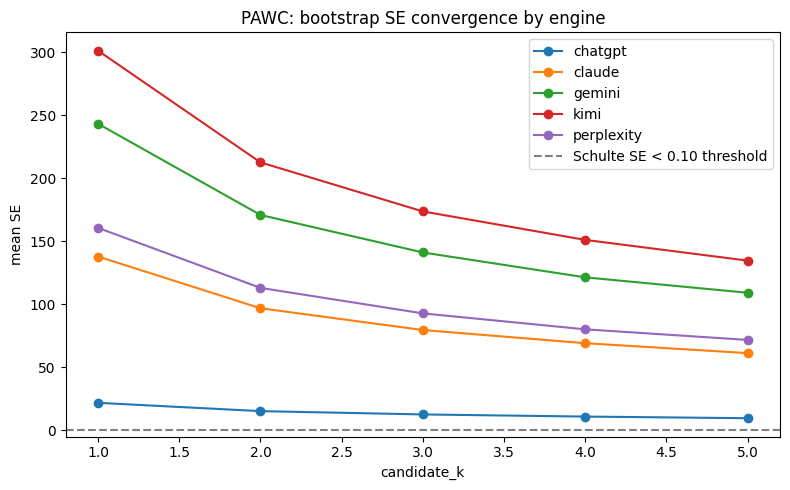

PosixPath('/Users/ganenthraravindran/Desktop/Thesis Data Pilot/figures/bootstrap_pawc.png')

In [15]:
# 6. Plot convergence curves — PAWC
metric = 'pawc_total'
plot_df = engine_curves[engine_curves['metric'] == metric]

plt.figure(figsize=(8, 5))
for engine, g in plot_df.groupby('engine'):
    g = g.sort_values('candidate_k')
    plt.plot(g['candidate_k'], g['mean_se'], marker='o', label=engine)

plt.axhline(0.10, color='gray', linestyle='--', label='Schulte SE < 0.10 threshold')
plt.title('PAWC: bootstrap SE convergence by engine')
plt.xlabel('candidate_k')
plt.ylabel('mean SE')
plt.legend(loc='upper right')
plt.tight_layout()
pawc_path = fig_dir / 'bootstrap_pawc.png'
plt.savefig(pawc_path, dpi=150)
plt.show()
pawc_path

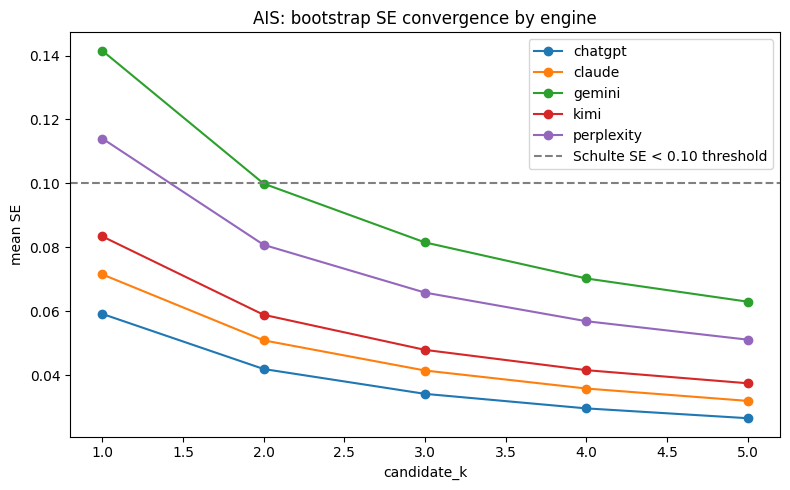

PosixPath('/Users/ganenthraravindran/Desktop/Thesis Data Pilot/figures/bootstrap_ais.png')

In [16]:
# 7. Plot convergence curves — AIS
metric = 'ais_rate'
plot_df = engine_curves[engine_curves['metric'] == metric]

plt.figure(figsize=(8, 5))
for engine, g in plot_df.groupby('engine'):
    g = g.sort_values('candidate_k')
    plt.plot(g['candidate_k'], g['mean_se'], marker='o', label=engine)

plt.axhline(0.10, color='gray', linestyle='--', label='Schulte SE < 0.10 threshold')
plt.title('AIS: bootstrap SE convergence by engine')
plt.xlabel('candidate_k')
plt.ylabel('mean SE')
plt.legend(loc='upper right')
plt.tight_layout()
ais_path = fig_dir / 'bootstrap_ais.png'
plt.savefig(ais_path, dpi=150)
plt.show()
ais_path

In [17]:
# 8. Where does each engine reach SE < 0.10?
rows = []
for (engine, metric), g in engine_curves.groupby(['engine', 'metric']):
    g = g.sort_values('candidate_k')
    below = g[g['mean_se'] < 0.10]
    if below.empty:
        k_value = 'does not converge by k=5'
    else:
        k_value = int(below['candidate_k'].iloc[0])
    rows.append({
        'engine': engine,
        'metric': metric,
        'k for SE<0.10': k_value,
    })

k_table = pd.DataFrame(rows).sort_values(['engine', 'metric'])
print(k_table.to_string(index=False))

    engine     metric            k for SE<0.10
   chatgpt   ais_rate                        1
   chatgpt pawc_total does not converge by k=5
    claude   ais_rate                        1
    claude pawc_total does not converge by k=5
    gemini   ais_rate                        2
    gemini pawc_total does not converge by k=5
      kimi   ais_rate                        1
      kimi pawc_total does not converge by k=5
perplexity   ais_rate                        2
perplexity pawc_total does not converge by k=5


# 8b. Relative SE analysis
The Schulte 0.10 threshold assumes a roughly [0,1] metric scale, which is true for AIS but not for PAWC.
PAWC is measured in raw position-weighted word counts, so absolute SE values cannot be compared directly to 0.10.
Computing relative SE (bootstrap SE divided by the cell mean) puts both metrics on a comparable scale and is the correct reading for PAWC.
We therefore re-express convergence using relative SE and apply the 0.10 threshold in that normalized space.

In [18]:
# 8c. Compute relative SE per cell
cell_means = df.groupby(['engine', 'query_id'], as_index=False)[metrics].mean()
cell_means_long = cell_means.melt(
    id_vars=['engine', 'query_id'],
    value_vars=metrics,
    var_name='metric',
    value_name='cell_mean',
)

boot_rel = boot_long.merge(
    cell_means_long,
    on=['engine', 'query_id', 'metric'],
    how='left',
)
boot_rel['relative_se'] = boot_rel['se'] / boot_rel['cell_mean']
boot_rel.loc[
    boot_rel['cell_mean'].isna() | boot_rel['cell_mean'].eq(0),
    'relative_se',
] = np.nan

nan_cells = (
    cell_means_long
    .assign(is_nan=cell_means_long['cell_mean'].isna() | cell_means_long['cell_mean'].eq(0))
    .groupby(['engine', 'metric'], as_index=False)['is_nan']
    .sum()
    .rename(columns={'is_nan': 'nan_cells'})
)
print('NaN cells per (engine, metric):')
print(nan_cells.to_string(index=False))

relative_curves = (
    boot_rel
    .groupby(['engine', 'metric', 'candidate_k'], as_index=False)
    .agg(mean_relative_se=('relative_se', 'mean'))
)
print(relative_curves)

NaN cells per (engine, metric):
    engine     metric  nan_cells
   chatgpt   ais_rate         70
   chatgpt pawc_total         70
    claude   ais_rate         23
    claude pawc_total         23
    gemini   ais_rate         19
    gemini pawc_total         19
      kimi   ais_rate          1
      kimi pawc_total          1
perplexity   ais_rate          4
perplexity pawc_total          4
        engine      metric  candidate_k  mean_relative_se
0      chatgpt    ais_rate            1          0.695572
1      chatgpt    ais_rate            2          0.493476
2      chatgpt    ais_rate            3          0.403939
3      chatgpt    ais_rate            4          0.348175
4      chatgpt    ais_rate            5          0.312862
5      chatgpt  pawc_total            1          0.765085
6      chatgpt  pawc_total            2          0.537905
7      chatgpt  pawc_total            3          0.443228
8      chatgpt  pawc_total            4          0.383279
9      chatgpt  pawc_tota

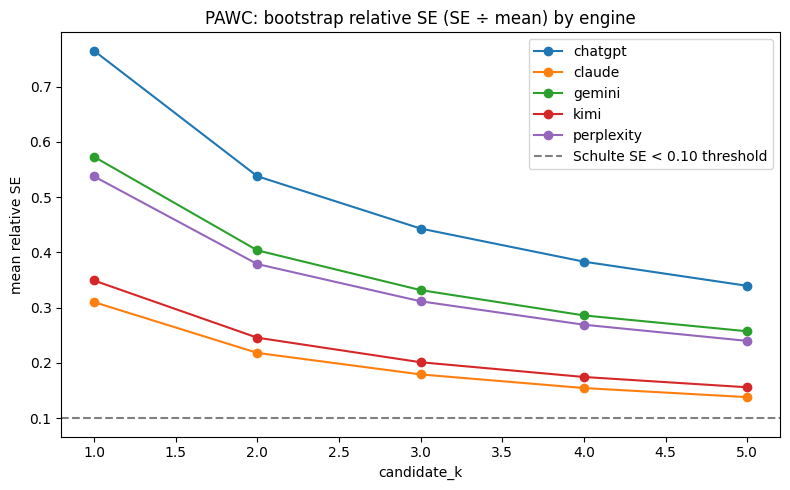

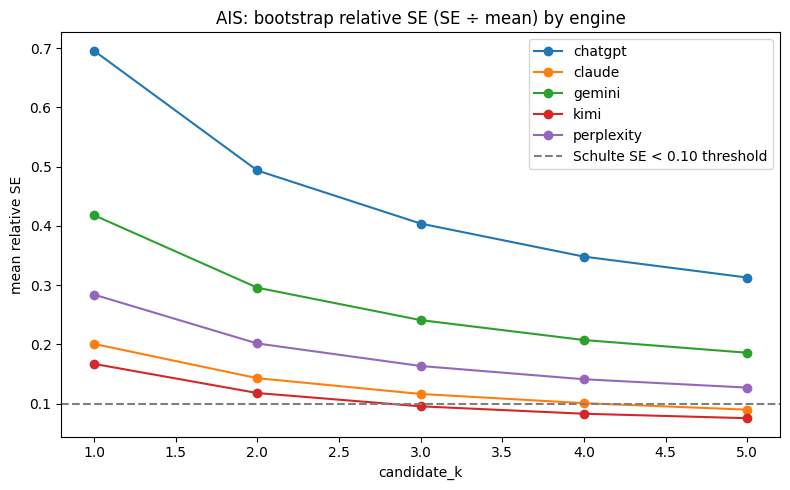

PosixPath('/Users/ganenthraravindran/Desktop/Thesis Data Pilot/figures/bootstrap_ais_relative.png')

In [19]:
# 8d. Plot relative SE convergence
metric = 'pawc_total'
plot_df = relative_curves[relative_curves['metric'] == metric]

plt.figure(figsize=(8, 5))
for engine, g in plot_df.groupby('engine'):
    g = g.sort_values('candidate_k')
    plt.plot(g['candidate_k'], g['mean_relative_se'], marker='o', label=engine)

plt.axhline(0.10, color='gray', linestyle='--', label='Schulte SE < 0.10 threshold')
plt.title('PAWC: bootstrap relative SE (SE ÷ mean) by engine')
plt.xlabel('candidate_k')
plt.ylabel('mean relative SE')
plt.legend(loc='upper right')
plt.tight_layout()
pawc_rel_path = fig_dir / 'bootstrap_pawc_relative.png'
plt.savefig(pawc_rel_path, dpi=150)
plt.show()
pawc_rel_path

metric = 'ais_rate'
plot_df = relative_curves[relative_curves['metric'] == metric]

plt.figure(figsize=(8, 5))
for engine, g in plot_df.groupby('engine'):
    g = g.sort_values('candidate_k')
    plt.plot(g['candidate_k'], g['mean_relative_se'], marker='o', label=engine)

plt.axhline(0.10, color='gray', linestyle='--', label='Schulte SE < 0.10 threshold')
plt.title('AIS: bootstrap relative SE (SE ÷ mean) by engine')
plt.xlabel('candidate_k')
plt.ylabel('mean relative SE')
plt.legend(loc='upper right')
plt.tight_layout()
ais_rel_path = fig_dir / 'bootstrap_ais_relative.png'
plt.savefig(ais_rel_path, dpi=150)
plt.show()
ais_rel_path

In [20]:
# 8e. Convergence k for relative SE < 0.10
rows = []
for (engine, metric), g in relative_curves.groupby(['engine', 'metric']):
    g = g.sort_values('candidate_k')
    below = g[g['mean_relative_se'] < 0.10]
    if below.empty:
        k_value = 'does not converge by k=5'
    else:
        k_value = int(below['candidate_k'].iloc[0])
    rows.append({
        'engine': engine,
        'metric': metric,
        'k for relative SE<0.10': k_value,
    })

relative_k_table = pd.DataFrame(rows).sort_values(['engine', 'metric'])
print(relative_k_table.to_string(index=False))

    engine     metric   k for relative SE<0.10
   chatgpt   ais_rate does not converge by k=5
   chatgpt pawc_total does not converge by k=5
    claude   ais_rate                        5
    claude pawc_total does not converge by k=5
    gemini   ais_rate does not converge by k=5
    gemini pawc_total does not converge by k=5
      kimi   ais_rate                        3
      kimi pawc_total does not converge by k=5
perplexity   ais_rate does not converge by k=5
perplexity pawc_total does not converge by k=5


# 9. Written conclusion
Absolute SE (sections 6-7) shows AIS reaches the 0.10 threshold quickly: chatgpt, claude, and kimi at k=1, with gemini and perplexity at k=2. The relative SE reading (sections 8c-8e) puts AIS on a comparable scale and shows kimi reaching <0.10 at k=3, claude at k=5, while chatgpt, gemini, and perplexity do not cross 0.10 by k=5. For PAWC, the relative SE curves do not cross 0.10 for any engine by k=5, which is the relevant convergence reading for that metric.

Absolute PAWC SE ranks chatgpt as lowest-variance, but this is a floor effect from its high zero-PAWC rate (many runs without search, yielding zero means and low absolute SE). The relative SE curves, and the earlier CV analysis, identify chatgpt as the least stable engine on a like-for-like basis, consistent with Schulte's chatgpt-least-stable finding and the pilot CV ordering. The methods chapter should therefore report the relative SE reading for PAWC; absolute PAWC SE rankings are misleading.

AIS has a comfortable margin under the absolute reading, but the relative-SE reading indicates several engines remain above 0.10 through k=5 because mean AIS is low in the pilot. For PAWC, relative SE stays above 0.10 through k=5 for all engines, so k=7 remains justified and likely still inside the convergence range rather than above it; reducing k would sacrifice PAWC precision. This bootstrap is built on only 3 observations per cell, so convergence beyond about k=4-5 is uncertain; Schulte's k=7-8 minimum remains the primary justification and this analysis is a confirmatory robustness check rather than a replacement.